# Insurance Premium Prediction Using SVR

The insurance.csv dataset contains 1338 observations (rows) and 7 features (columns).

The dataset contains 4 numerical features (age, bmi, children and expenses) and 3 nominal features (sex, smoker and region) that were converted into factors with numerical value desginated for each level.

## Problem Definition: Medical Insurance Analysis

###Features and Target Variable
In this dataset, we are trying to predict a continuous numerical value, making this a Regression problem.

- Target Variable ($y$):

  Expenses, which si the total medical cost billed by health insurance.

- Feature Variables ($X$):

  Numerical: age, bmi, children.  Categorical: sex, smoker, region


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error


In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# Exploratory Data Analysis (EDA)

In [3]:
print(df.head())

   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


Text(0.5, 1.0, 'Distribution of Insurance Expenses')

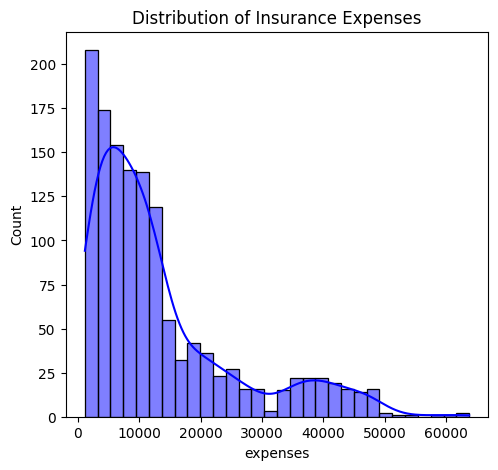

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['expenses'], kde=True, color='blue')
plt.title('Distribution of Insurance Expenses')

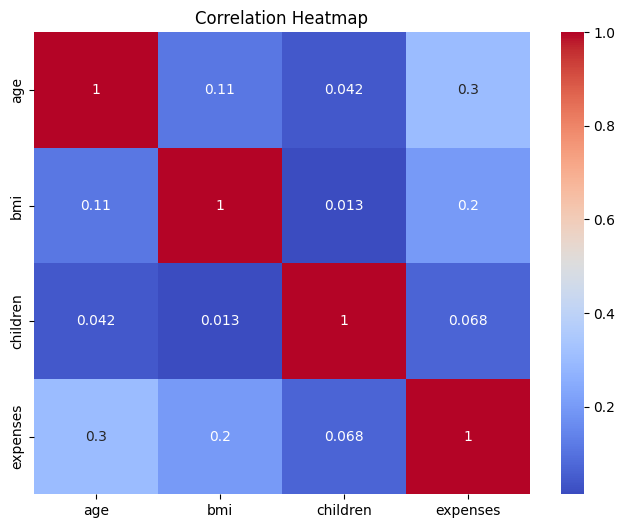

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

- Age and Expenses: There is a positive correlation (0.3) between age and medical expenses. This means that as a person gets older, their medical costs generally tend to increase.

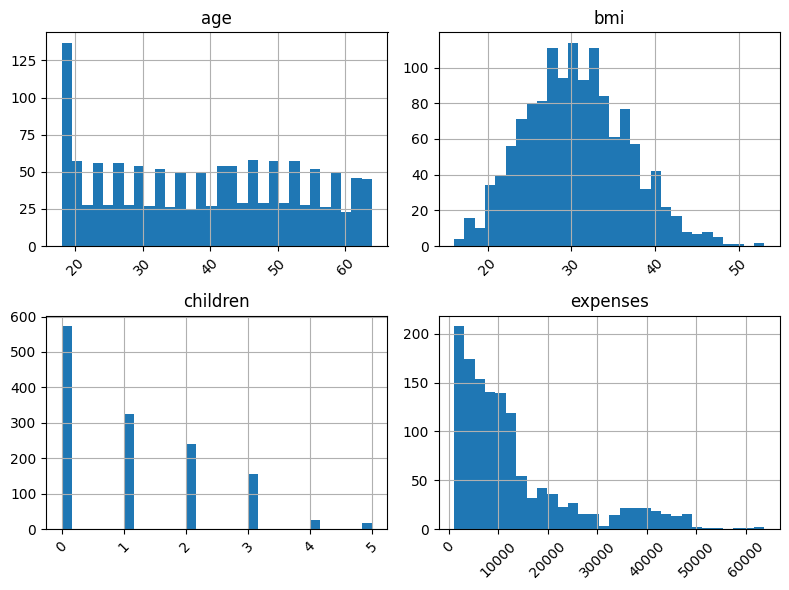

In [8]:
hists = df.hist(figsize=(8, 6), bins=30,)
for ax in hists.flatten():
  ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

We can see here that the age's most common value was 20, while the other ages are distributed consistantly.
The bmi has a normal distribution according to the histogram which is a good indicator.
the number of samples decreases as the number of children increases which means the majority had less children.
The frequency of expense amounts decreases as amount increases, indicating people billed larger amounts are less than those who are billed smaller ones.

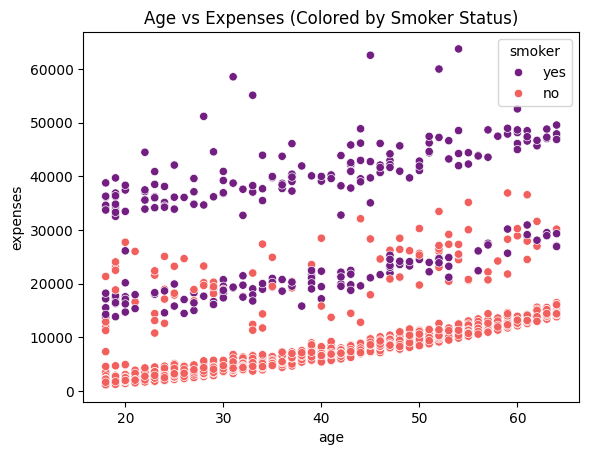

In [9]:
sns.scatterplot(data=df, x='age', y='expenses', hue='smoker', palette='magma')
plt.title('Age vs Expenses (Colored by Smoker Status)')
plt.show()

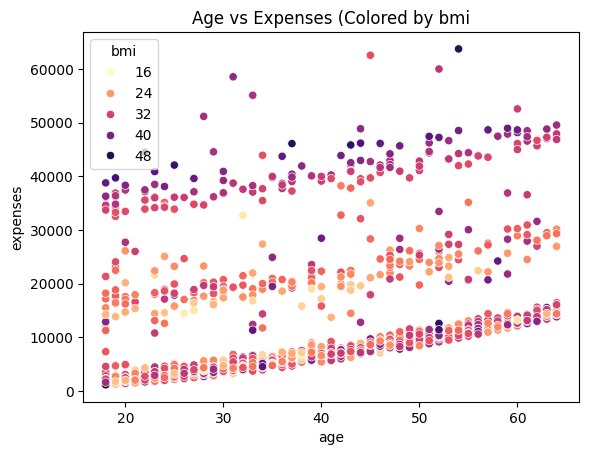

In [12]:
sns.scatterplot(data=df, x='age', y='expenses', hue='bmi', palette='magma_r')
plt.title('Age vs Expenses (Colored by bmi')
plt.show()

**Analysis: Age vs. Medical Expenses**

Strong Positive Correlation: There is a clear upward trend; as age increases, medical expenses naturally rise for all groups.

The "Smoker" Gap: Smoking status is the most significant driver of cost. Smokers (top two tiers) consistently have much higher expenses than non-smokers, even at younger ages.

Three Distinct Clusters:

1.  Bottom Tier: Non-smokers with standard health.
2.  Middle Tier: Non-smokers with complications or smokers with low BMIs.
3.  Top Tier: Smokers with high BMIs (representing the highest financial risk).

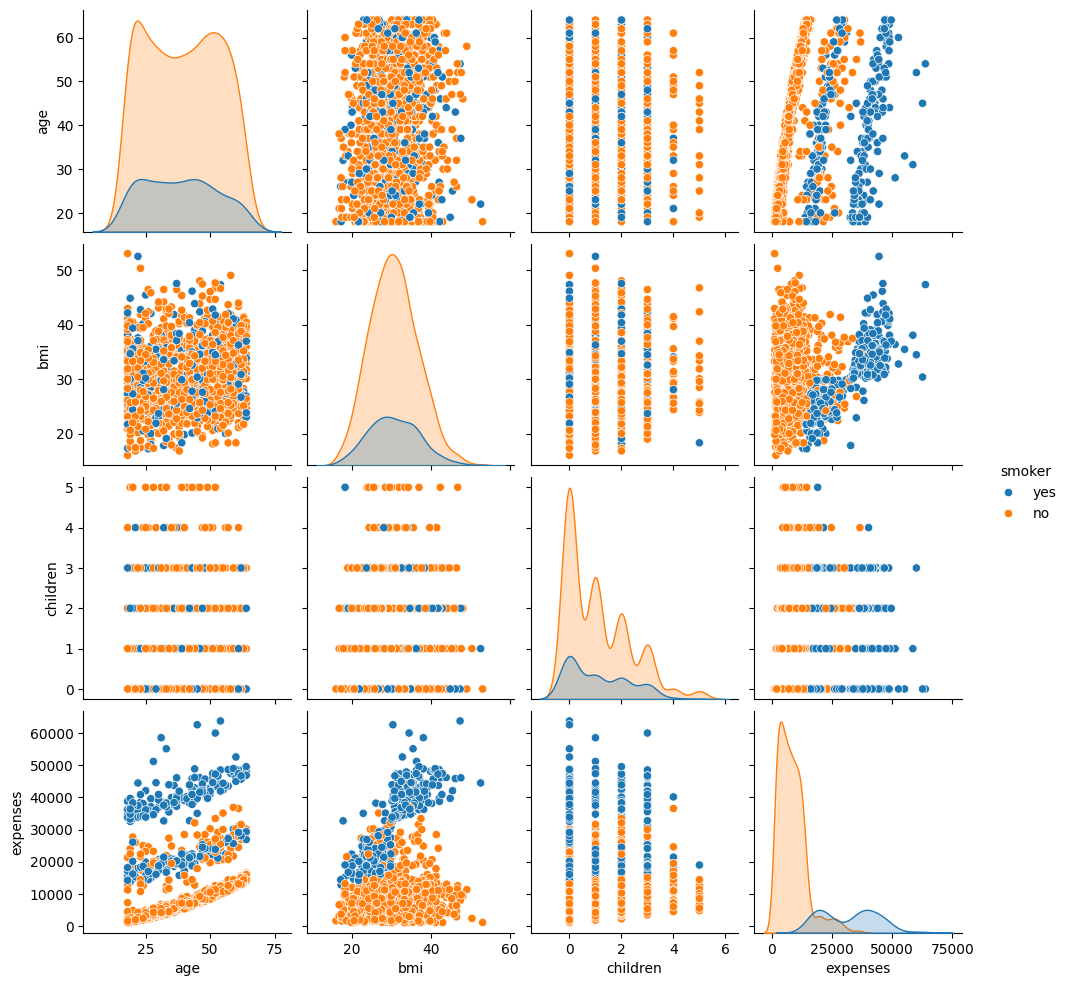

In [ ]:
# This creates a grid of scatter plots for all numeric columns
sns.pairplot(df, hue='smoker', diag_kind='kde')
plt.show()

**Cost Gap:** Smokers consistently fall into the highest expense brackets. Even a young smoker (age 18–20) often incurs higher medical costs than a non-smoker in their 60s.

**The BMI Multiplier:** The scatter plots show that for non-smokers, high BMI has a small effect on cost. However, for smokers, once BMI exceeds 30, expenses skyrocket exponentially.

**Distribution Shift:** In the density plots (diagonal), non-smokers are clustered at the low end (left), while smokers create a completely separate, higher-cost distribution (right).


# Data Processing

In [ ]:
# Encoding categorical features
df_copy = df.copy()
df = pd.get_dummies(df, drop_first=True, dtype=int)
df


,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,0,1,0,0,1
1,18,33.8,1,1725.55,1,0,0,1,0
2,28,33.0,3,4449.46,1,0,0,1,0
3,33,22.7,0,21984.47,1,0,1,0,0
4,32,28.9,0,3866.86,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,31.0,3,10600.55,1,0,1,0,0
1334,18,31.9,0,2205.98,0,0,0,0,0
1335,18,36.9,0,1629.83,0,0,0,1,0
1336,21,25.8,0,2007.95,0,0,0,0,1


All features were included.

age: Older people generally have higher medical costs. Strong predictor.

bmi: Higher BMI usually correlates with more medical expenses.

children:	More dependents can increase insurance costs.

sex: Can have small effect (some studies show males/females differ slightly in cost).


smoker:	Very strong predictor — smokers almost always have higher medical expenses.

region:	Insurance pricing can vary by region. Include to account for geographic differences.

In [ ]:
X = df[["age", "bmi","children","sex_male","smoker_yes", "region_northwest","region_southeast"]]
y = df["expenses"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#scale numeric features
numeric_columns = ['age', 'bmi', 'children']
scaler_X = StandardScaler()
X_train[numeric_columns] = scaler_X.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler_X.transform(X_test[numeric_columns])

#scale target for SVR
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

#Support vector regression
model = SVR()
model.fit(X_train, y_train_scaled)

y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()



In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R² score): {r2:.4f}")

'''
MAE: 2,488.29 → average predictions are off by about $2,488
MSE: 23,823,365.15 large errors are squared, giving a sense of extreme outliers
RMSE: 4,880.92  prediction error magnitude; more sensitive to large errors than MAE
R²: 0.8465  model explains 84.65% of the variance in expenses very good
'''

Mean Absolute Error (MAE): 2488.29
Mean Squared Error (MSE): 23823365.15
Root Mean Squared Error (RMSE): 4880.92
R-squared (R² score): 0.8465


'\nMAE: 2,488.29 → average predictions are off by about $2,488\nMSE: 23,823,365.15 large errors are squared, giving a sense of extreme outliers\nRMSE: 4,880.92  prediction error magnitude; more sensitive to large errors than MAE\nR²: 0.8465  model explains 84.65% of the variance in expenses very good\n'

# Optimizing the Model: Tuning for Insurance Data

In [ ]:
#         Model Tuning Phase
from sklearn.model_selection import GridSearchCV

# Define the parameter grid based on our understanding of C, Gamma, and Epsilon
param_grid = {
    'C': [1, 10, 100],          # Testing different penalty levels for errors
    'gamma': [0.1, 0.01, 1],    # Testing different ranges of influence for data points
    'epsilon': [0.1, 0.2],      # Defining the width of the error-free zone (the tube)
    'kernel': ['rbf']           # Using RBF kernel to handle non-linear insurance data
}

# Searching for the best combination of hyperparameters using Cross-Validation
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=0, cv=5)
grid.fit(X_train, y_train_scaled)

# Display the optimal parameters selected for the insurance dataset
print(f"Best Parameters: {grid.best_params_}")

# Re-predicting using the optimized model
best_model = grid.best_estimator_
y_pred_best_scaled = best_model.predict(X_test)
y_pred_best = scaler_y.inverse_transform(y_pred_best_scaled.reshape(-1,1)).ravel()

# Evaluating the improved performance (Expected to exceed the baseline 84%)
new_r2 = r2_score(y_test, y_pred_best)
print(f"Improved R2 Score: {new_r2:.4f}")

'''
To optimize the results, GridSearchCV was applied, improving the R² score
from 0.8465 to 0.8573. The best configuration was found at C=10 and Gamma=0.1.
This fine-tuning effectively balanced the model's complexity, allowing it to
capture non-linear trends while remaining robust against insurance cost outliers
'''

Best Parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 0.1, 'kernel': 'rbf'}
Improved R2 Score: 0.8573


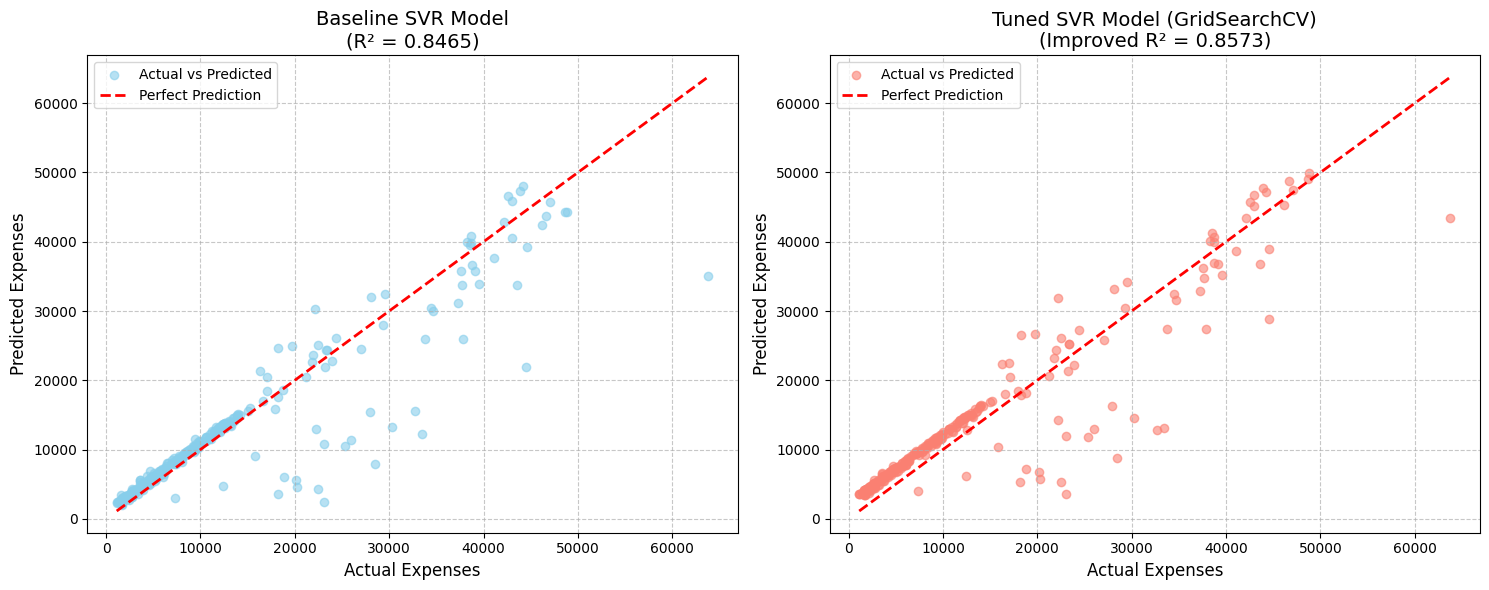

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# (Baseline SVR)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='skyblue', alpha=0.6, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Baseline SVR Model\n(R² = {r2:.4f})', fontsize=14)
plt.xlabel('Actual Expenses', fontsize=12)
plt.ylabel('Predicted Expenses', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# (Tuned SVR)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_best, color='salmon', alpha=0.6, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Tuned SVR Model (GridSearchCV)\n(Improved R² = {new_r2:.4f})', fontsize=14)
plt.xlabel('Actual Expenses', fontsize=12)
plt.ylabel('Predicted Expenses', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Conclusion

After properly preprocessing the dataset, encoding categorical variables, scaling numeric features, and scaling the target, the Support Vector Regression (SVR) model effectively captured the relationships between the features and medical expenses.

Initially, the baseline model achieved an **R²** of **0.8465**. However, by implementing Hyperparameter Tuning via GridSearchCV, the model was further optimized. By fine-tuning the 'Control Knobs'—specifically **C=10**, **Gamma=0.1**, and **Epsilon=0.2** the performance improved to an Improved R² of **0.8573**.

While the MAE (**2,488**) and RMSE (**4,881**) indicate that predictions are generally accurate, the tuning process helped the model better navigate the trade-off between simplicity and sensitivity to outliers (such as high-cost smokers). This demonstrates that while the initial approach was sound, systematic optimization is essential for maximizing predictive accuracy in complex insurance datasets.